In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv("AmesHousing.csv")

df.info()
print(df.dtypes.value_counts())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


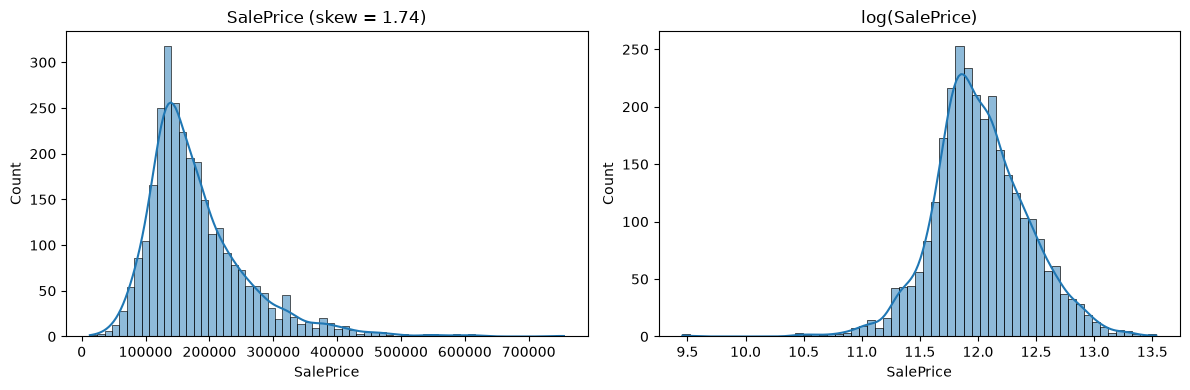

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew = {df['SalePrice'].skew():.2f})")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log(SalePrice)")

plt.tight_layout()
plt.show()

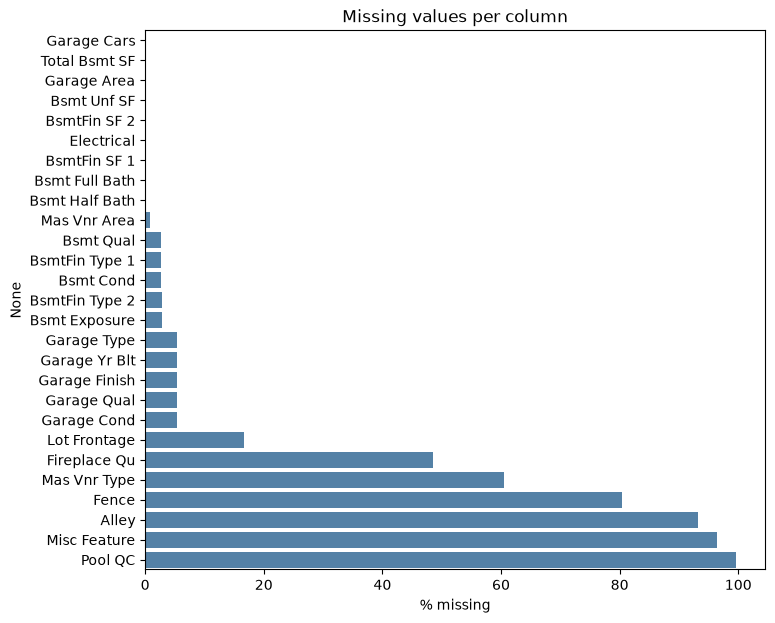

In [117]:
missing = df.isna().mean().mul(100).sort_values(ascending=True)
missing = missing[missing > 0]

plt.figure(figsize=(8, 7))
sns.barplot(x=missing.values, y=missing.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values per column")
plt.show()

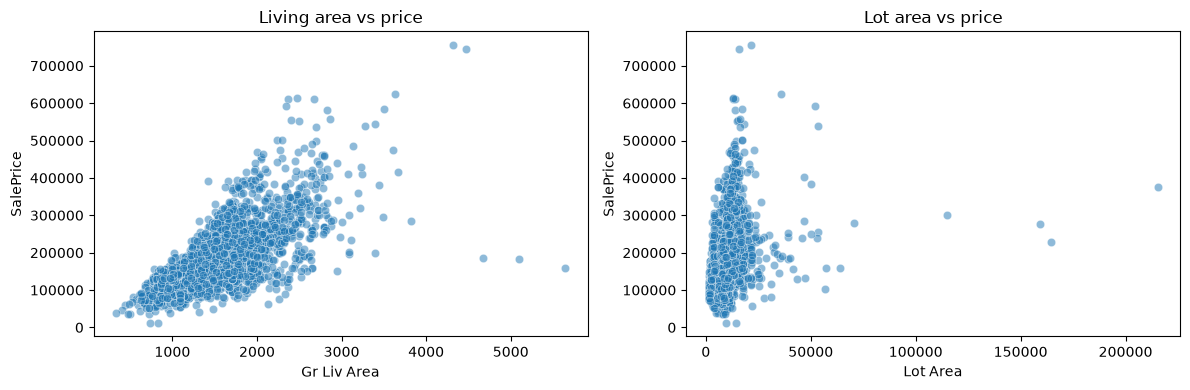

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=df, x="Gr Liv Area", y="SalePrice", alpha=0.5, ax=axes[0])
axes[0].set_title("Living area vs price")

sns.scatterplot(data=df, x="Lot Area", y="SalePrice", alpha=0.5, ax=axes[1])
axes[1].set_title("Lot area vs price")

plt.tight_layout()
plt.show()

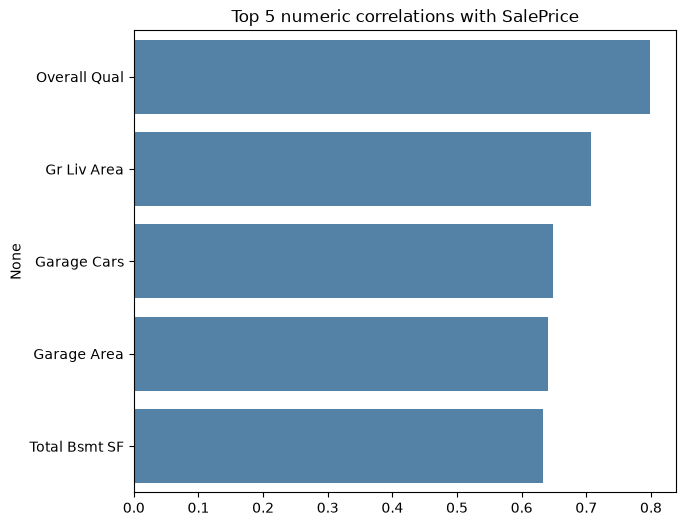

In [129]:
corr = df.corr(numeric_only=True)["SalePrice"].drop("SalePrice")
top = corr.reindex(corr.abs().sort_values(ascending=False).index)[:5]

plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index, color="steelblue")
plt.title("Top 5 numeric correlations with SalePrice")
plt.show()

In [ ]:
#Preprocess
X = df.drop(columns=["SalePrice","Order", "PID"])
y = df["SalePrice"]

X["MS SubClass"] = X["MS SubClass"].astype(str) #These are numbers that are used for catogorization, so we turn them into string.
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42)

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols), #For values that are missing we fill it with the median, which is the standard.
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="None")), #For catagories where the feature is missing, we fill it with the string "None"
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)), #Ignore catogories never seen before.
    ]), cat_cols),
])

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test) 

In [141]:
#Training
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(random_state=42),
}

In [142]:
#Testing
results = []
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    pred = model.predict(X_test_prep)
    results.append({
        "Model": name,
        "Test RMSE": root_mean_squared_error(y_test, pred),
        "Test R²": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                      Model  Test RMSE  Test R²
0         Linear Regression  28931.689    0.896
1  Decision Tree Regression  34967.167    0.847
2  Random Forest Regression  26462.550    0.913
